# Convulational neural networks with PyTorch

## PyTorch Setup

In [134]:
import torch

In [135]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_device(device)
print(f"Using device: {device}")

Using device: cuda


## Load the dataset

In [136]:
from torchvision.datasets import CIFAR10
from torchvision import transforms

In [137]:
transform = transforms.ToTensor()
train_data = CIFAR10(root="./data", train=True, download=True, transform=transform)
test_data = CIFAR10(root="./data", train=False, download=True, transform=transform)

c:\Users\oscar\repos\clases-cetys\computational-intelligence\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [138]:
train_data

Dataset CIFAR10
    Number of datapoints: 50000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [139]:
test_data

Dataset CIFAR10
    Number of datapoints: 10000
    Root location: ./data
    Split: Test
    StandardTransform
Transform: ToTensor()

## Defining the neural network

In [140]:
import torch.nn as nn
import torch.optim as optim

In [141]:
input_shape = train_data[0][0].shape
input_shape


torch.Size([3, 32, 32])

In [142]:
output_shape = train_data.classes.__len__()
print(output_shape)

10


In [143]:
model1 = nn.Sequential(
    nn.Conv2d(input_shape[0], 16, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),

    nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),

    nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),

    nn.Flatten(),
    nn.Linear(64 * 4 * 4, output_shape)
).to(device)

model2 = nn.Sequential(
    nn.Conv2d(input_shape[0], 32, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),

    nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),

    nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),

    nn.Flatten(),
    nn.Dropout(0.30),
    nn.Linear(128 * 4 * 4, output_shape)
).to(device)

model3 = nn.Sequential(
    nn.Conv2d(input_shape[0], 24, kernel_size=5, stride=1, padding=2),
    nn.ReLU(),
    nn.AvgPool2d(kernel_size=2, stride=2),

    nn.Conv2d(24, 48, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.AvgPool2d(kernel_size=2, stride=2),

    nn.Conv2d(48, 96, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2, stride=2),

    nn.Flatten(),
    nn.Linear(96 * 4 * 4, 256),
    nn.ReLU(),
    nn.Dropout(0.40),
    nn.Linear(256, output_shape)
).to(device)

optimizer2 = optim.Adam(model2.parameters(), lr=1e-3)
optimizer3 = optim.Adam(model3.parameters(), lr=1e-3)


loss_function = nn.CrossEntropyLoss()
optimizer1 = optim.Adam(model1.parameters())

## Mini-batches function

In [144]:
import numpy as np

In [145]:
def create_minibatches(batch_size, x, y):
    total_data = len(x)
    indices = np.arange(total_data)

    for i in range(0, total_data, batch_size):
        batch_idx = indices[i:i + batch_size]
        x_batch = torch.stack([x[j] for j in batch_idx])
        y_batch = torch.tensor([y[j] for j in batch_idx], dtype=torch.long)
        yield x_batch, y_batch

## Train function

In [146]:
from tqdm import tqdm

In [147]:
def train(model, train_data, val_data, optimizer, criterion, epochs, batch_size, patience=None, delta=0.005):
    # Training data
    x_data = [x for x, _ in train_data]
    y_data = [y for _, y in train_data]

    # Validation data
    x_val = [x for x, y in val_data]
    y_val = [y for _, y in val_data]

    res = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
    }

    for epoch in range(epochs):
        # Train
        model.train()
        running_loss = 0.0
        train_correct = 0
        train_total = 0

        epoch_iterator = tqdm(
            create_minibatches(batch_size, x_data, y_data),
            total=(len(train_data) + batch_size - 1) // batch_size,
            desc=f"Epoch {epoch+1}/{epochs}",
            leave=True
        )

        for inputs, labels in epoch_iterator:
            optimizer.zero_grad()
            if inputs.device != device:
                inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            # Accuracy
            preds = outputs.argmax(dim=1)
            train_correct += (preds == labels).sum().item()
            train_total += labels.size(0)

            running_loss += loss.item() * len(inputs)

        epoch_train_loss = running_loss / len(train_data)
        epoch_train_accuracy = train_correct / train_total

        # Eval
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for inputs, labels in create_minibatches(batch_size, x_val, y_val):
                if inputs.device != device:
                    inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                # Accuracy
                preds = outputs.argmax(dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)

                val_loss += loss.item() * len(inputs)
        
        epoch_val_loss = val_loss / len(val_data)
        epoch_val_accuracy = val_correct / val_total

        res['train_loss'].append(epoch_train_loss)
        res['train_acc'].append(epoch_train_accuracy)
        res['val_loss'].append(epoch_val_loss)
        res['val_acc'].append(epoch_val_accuracy)

        print(f"Epoch [{epoch+1}/{epochs}], Loss: {epoch_train_loss:.4f}, Val Loss: {epoch_val_loss:.4f}, Train Acc: {epoch_train_accuracy:.4f}, Val Acc: {epoch_val_accuracy:.4f}")

        # Early stopping
        if patience is not None:
            if epoch == 0:
                best_val_loss = epoch_val_loss
                patience_counter = 0
            else:
                if epoch_val_loss < best_val_loss - delta:
                    best_val_loss = epoch_val_loss
                    patience_counter = 0
                else:
                    patience_counter += 1

            if patience_counter >= patience:
                print(f"Early stop triggered")
                break

    return epoch_train_loss, epoch_val_loss, epoch_train_accuracy, epoch_val_accuracy, res

In [148]:
model1_metrics = train(
    model=model1,
    train_data=train_data,
    val_data=test_data,
    optimizer=optimizer1,
    criterion=loss_function,
    epochs=30,
    batch_size=64,
    patience=5
)
model1_metrics

Epoch 1/30: 100%|██████████| 782/782 [00:03<00:00, 241.15it/s]


Epoch [1/30], Loss: 1.6063, Val Loss: 1.3343, Train Acc: 0.4190, Val Acc: 0.5242


Epoch 2/30: 100%|██████████| 782/782 [00:03<00:00, 241.05it/s]


Epoch [2/30], Loss: 1.2683, Val Loss: 1.1722, Train Acc: 0.5502, Val Acc: 0.5859


Epoch 3/30: 100%|██████████| 782/782 [00:02<00:00, 273.44it/s]


...

Epoch 11/30: 100%|██████████| 782/782 [00:02<00:00, 288.17it/s]


Epoch [11/30], Loss: 0.7189, Val Loss: 0.9392, Train Acc: 0.7526, Val Acc: 0.6885


Epoch 12/30: 100%|██████████| 782/782 [00:03<00:00, 255.12it/s]


Epoch [12/30], Loss: 0.6957, Val Loss: 0.9414, Train Acc: 0.7603, Val Acc: 0.6901
Early stop triggered


(0.6957381956291199,
 0.9414287157058716,
 0.76028,
 0.6901,
 {'train_loss': [1.6063215060424805,
   1.2682578649139404,
   1.1207957692337036,
   1.0179628795623779,
   0.945129007987976,
   0.8897353989219665,
   0.8449669609069824,
   0.8063109305000306,
   0.7734865803718567,
   0.7441914052009583,
   0.7189230657386779,
   0.6957381956291199],
  'train_acc': [0.41902,
   0.55024,
   0.60724,
   0.64316,
   0.67012,
   0.69014,
   0.70682,
   0.72056,
   0.73174,
   0.74338,
   0.75258,
   0.76028],
  'val_loss': [1.334348519897461,
   1.1722386814117431,
   1.0605623275756837,
   0.9953331884384156,
   0.9682886385917664,
   0.9519926506042481,
   0.939552331161499,
   0.9395622915267944,
   0.9420101234436035,
   0.9379432077407837,
   0.9391517848968506,
   0.9414287157058716],
  'val_acc': [0.5242,
   0.5859,
   0.6221,
   0.6528,
   0.6658,
   0.6742,
   0.6776,
   0.6805,
   0.6818,
   0.6841,
   0.6885,
   0.6901]})

In [149]:
model2_metrics = train(
    model=model2,
    train_data=train_data,
    val_data=test_data,
    optimizer=optimizer2,
    criterion=loss_function,
    epochs=30,
    batch_size=64,
    patience=5
)
model2_metrics

Epoch 1/30: 100%|██████████| 782/782 [00:03<00:00, 253.70it/s]


Epoch [1/30], Loss: 1.5473, Val Loss: 1.2394, Train Acc: 0.4421, Val Acc: 0.5594


Epoch 2/30: 100%|██████████| 782/782 [00:03<00:00, 254.05it/s]


Epoch [2/30], Loss: 1.1632, Val Loss: 1.0267, Train Acc: 0.5900, Val Acc: 0.6410


Epoch 3/30: 100%|██████████| 782/782 [00:02<00:00, 263.38it/s]


...

Epoch 15/30: 100%|██████████| 782/782 [00:03<00:00, 253.39it/s]


Epoch [15/30], Loss: 0.5378, Val Loss: 0.7423, Train Acc: 0.8088, Val Acc: 0.7495


Epoch 16/30: 100%|██████████| 782/782 [00:03<00:00, 253.16it/s]


Epoch [16/30], Loss: 0.5257, Val Loss: 0.7297, Train Acc: 0.8138, Val Acc: 0.7588
Early stop triggered


(0.5257243150234222,
 0.729672675895691,
 0.81384,
 0.7588,
 {'train_loss': [1.5472802111434936,
   1.1632433473968506,
   0.9999852415466308,
   0.8965105979156495,
   0.8331414136505126,
   0.7818931982040406,
   0.7395199462509155,
   0.7042445174980163,
   0.6728652886009217,
   0.6443671262168884,
   0.6193616963768005,
   0.6030792192363739,
   0.5789484732532502,
   0.5636917581367493,
   0.5377960324287414,
   0.5257243150234222],
  'train_acc': [0.44214,
   0.59,
   0.65262,
   0.69026,
   0.70948,
   0.72864,
   0.7433,
   0.75626,
   0.7657,
   0.7746,
   0.78378,
   0.78898,
   0.79718,
   0.80256,
   0.80884,
   0.81384],
  'val_loss': [1.2393958139419556,
   1.026701061630249,
   0.9030122441291809,
   0.8633181056976318,
   0.8204507873535156,
   0.7780799381256104,
   0.7947628232955932,
   0.7455847382545471,
   0.7497558672904968,
   0.7415010551452637,
   0.7251394247055054,
   0.7238807987213135,
   0.730298610496521,
   0.7294959400177002,
   0.7422560732841492,
  

In [150]:
model3_metrics = train(
    model=model3,
    train_data=train_data,
    val_data=test_data,
    optimizer=optimizer3,
    criterion=loss_function,
    epochs=30,
    batch_size=64,
    patience=5
)

Epoch 1/30: 100%|██████████| 782/782 [00:03<00:00, 211.44it/s]


Epoch [1/30], Loss: 1.7032, Val Loss: 1.4413, Train Acc: 0.3765, Val Acc: 0.4724


Epoch 2/30: 100%|██████████| 782/782 [00:03<00:00, 230.67it/s]


Epoch [2/30], Loss: 1.3851, Val Loss: 1.2921, Train Acc: 0.5032, Val Acc: 0.5383


Epoch 3/30: 100%|██████████| 782/782 [00:03<00:00, 231.00it/s]


...

Epoch [14/30], Loss: 0.6154, Val Loss: 0.9104, Train Acc: 0.7790, Val Acc: 0.7095


Epoch 15/30: 100%|██████████| 782/782 [00:03<00:00, 215.08it/s]


Epoch [15/30], Loss: 0.5936, Val Loss: 0.9271, Train Acc: 0.7892, Val Acc: 0.7098


Epoch 16/30: 100%|██████████| 782/782 [00:03<00:00, 212.40it/s]


Epoch [16/30], Loss: 0.5573, Val Loss: 0.9307, Train Acc: 0.7982, Val Acc: 0.7124
Early stop triggered


## Loss curves

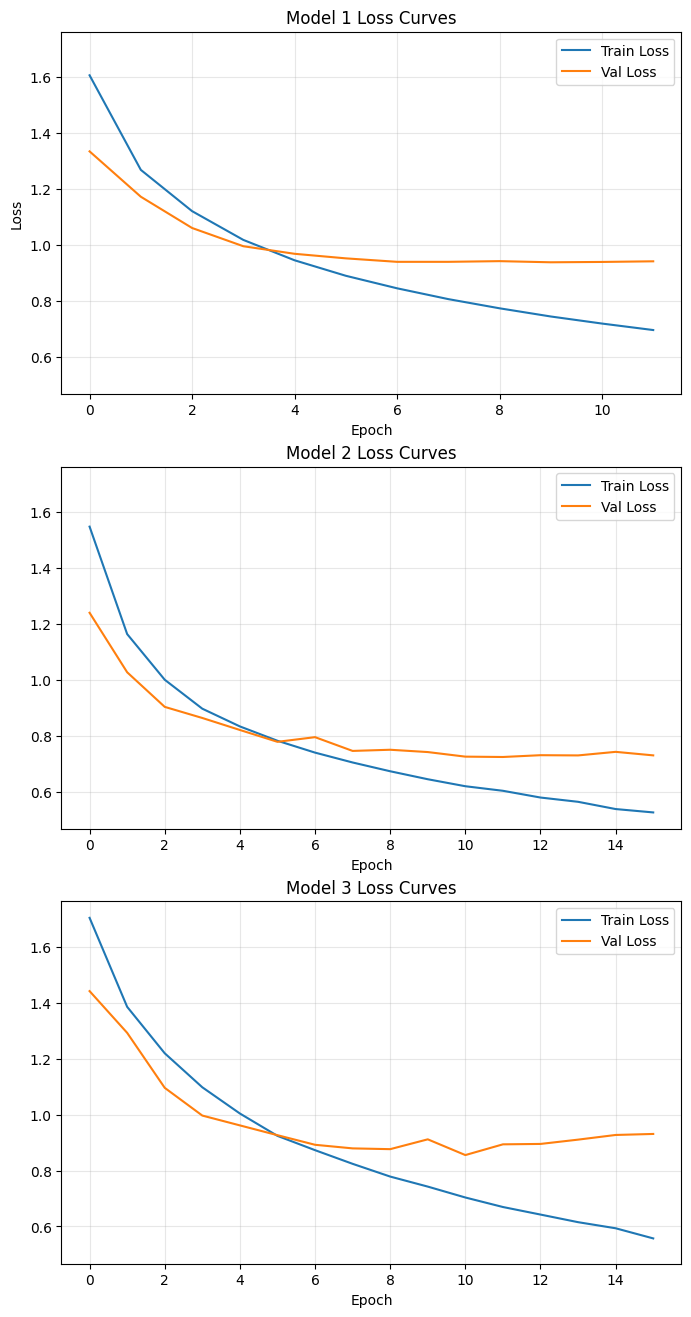

In [162]:
import matplotlib.pyplot as plt

histories = {
    "Model 1": model1_metrics[4],
    "Model 2": model2_metrics[4],
    "Model 3": model3_metrics[4],
}

fig, axes = plt.subplots(3, 1, figsize=(8,16), sharey=True)

for ax, (model_name, res) in zip(axes, histories.items()):
    ax.plot(res["train_loss"], label="Train Loss")
    ax.plot(res["val_loss"], label="Val Loss")
    ax.set_title(f"{model_name} Loss Curves")
    ax.set_xlabel("Epoch")
    ax.grid(True, alpha=0.3)
    ax.legend()

axes[0].set_ylabel("Loss")
plt.show()

## Models evaluation

In [152]:
def evaluate_model(model, dataset, criterion, batch_size=256):
    x_data = [x for x, _ in dataset]
    y_data = [y for _, y in dataset]

    model.eval()
    total_loss = 0.0
    test_correct = 0
    test_total = 0

    with torch.no_grad():
        for inputs, labels in create_minibatches(batch_size, x_data, y_data):
            if inputs.device != device:
                inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            preds = outputs.argmax(dim=1)
            test_correct += (preds == labels).sum().item()
            test_total += labels.size(0)
            total_loss += loss.item() * labels.size(0)

    return {
        "test_loss": total_loss / test_total,
        "test_accuracy": test_correct / test_total,
    }


models = {
    "Model 1": model1,
    "Model 2": model2,
    "Model 3": model3,
}

results = {}
for name, model in models.items():
    metrics = evaluate_model(model, test_data, loss_function, batch_size=256)
    results[name] = metrics
    print(
        f"{name} = Test Loss: {metrics['test_loss']:.4f}, Test Accuracy: {metrics['test_accuracy']:.4f}"
    )

# Get the best model
best_name = max(results, key=lambda k: results[k]["test_accuracy"])
best_metrics = results[best_name]

print("\nBest model:", best_name)
print(
    f"{best_name} Test Loss: {best_metrics['test_loss']:.4f}, {best_name} Test Accuracy: {best_metrics['test_accuracy']:.4f}"
)

Model 1 = Test Loss: 0.9414, Test Accuracy: 0.6901
Model 2 = Test Loss: 0.7297, Test Accuracy: 0.7589
Model 3 = Test Loss: 0.9307, Test Accuracy: 0.7124

Best model: Model 2
Model 2 Test Loss: 0.7297, Model 2 Test Accuracy: 0.7589


## Reflection

In this practice, I learned how convolutional neural networks can detect specific image patterns even when those patterns appear in different positions. I had problems understanding convolutional layers and tracking input/output dimensions across the network but it eventualy become clearer.

After comparing the three architectures, Model 2 performed the best overall. It achieved better accuracy with lower loss.